# HW12: временные ряды, baseline и GRU

В ноутбуке реализованы все обязательные пункты задания:
- sanity-check данных;
- temporal split `train/validation/test` по времени;
- baseline-эксперименты `B1`, `B2`, `B3`;
- GRU-эксперимент `R1` на оконном представлении;
- выбор лучшей модели по validation;
- финальная оценка лучшей модели на test;
- сохранение обязательных артефактов в `artifacts/`.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

In [2]:
SEED = 42
WINDOW_SIZE = 24
MOVING_AVG_WINDOW = 24
EPOCHS = 40
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
HORIZON = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

ROOT = Path('.')
ARTIFACTS_DIR = ROOT / 'artifacts'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Device: cpu


Rows: 4320
Date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
Missing values by column:
date      0
target    0
dtype: int64


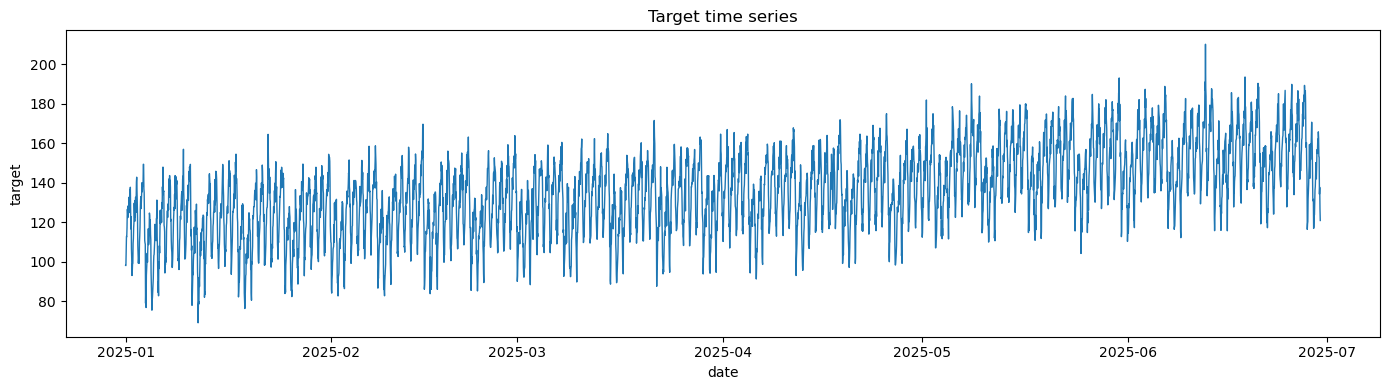

Комментарий: ряд часовой, выражена сезонность внутри суток, есть плавные изменения уровня. Random split здесь некорректен, потому что нарушает причинный порядок времени и приводит к утечке информации.


In [3]:
df = pd.read_csv(ROOT / 'S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Rows:', len(df))
print('Date range:', df['date'].min(), '->', df['date'].max())
print('Missing values by column:')
print(df.isna().sum())

plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['target'], lw=1.0)
plt.title('Target time series')
plt.xlabel('date')
plt.ylabel('target')
plt.tight_layout()
plt.show()

print('Комментарий: ряд часовой, выражена сезонность внутри суток, есть плавные изменения уровня. Random split здесь некорректен, потому что нарушает причинный порядок времени и приводит к утечке информации.')

train: 2025-01-01 00:00:00 -> 2025-05-06 23:00:00 rows= 3024
validation: 2025-05-07 00:00:00 -> 2025-06-02 23:00:00 rows= 648
test: 2025-06-03 00:00:00 -> 2025-06-29 23:00:00 rows= 648


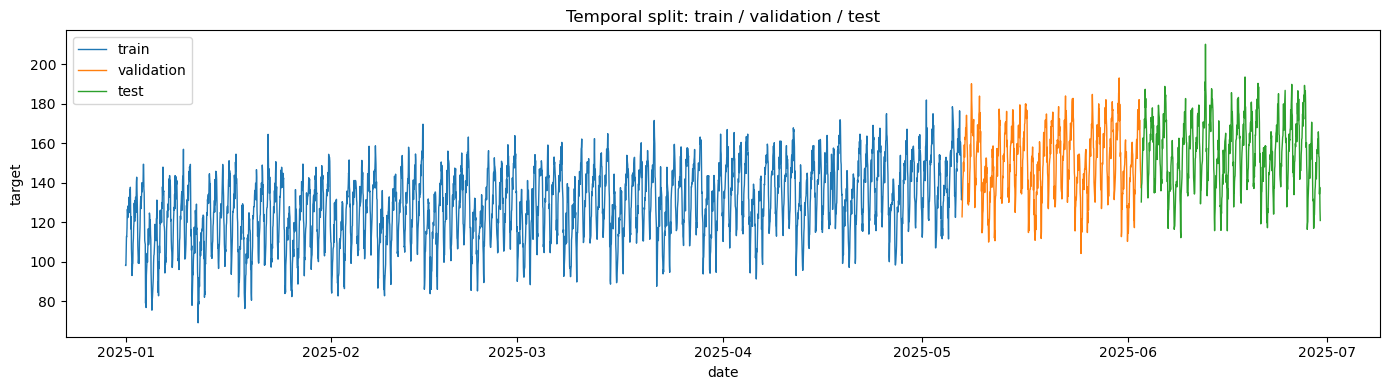

In [4]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print('train:', train_df['date'].min(), '->', train_df['date'].max(), 'rows=', len(train_df))
print('validation:', val_df['date'].min(), '->', val_df['date'].max(), 'rows=', len(val_df))
print('test:', test_df['date'].min(), '->', test_df['date'].max(), 'rows=', len(test_df))

plt.figure(figsize=(14, 4))
plt.plot(train_df['date'], train_df['target'], label='train', lw=1)
plt.plot(val_df['date'], val_df['target'], label='validation', lw=1)
plt.plot(test_df['date'], test_df['target'], label='test', lw=1)
plt.title('Temporal split: train / validation / test')
plt.xlabel('date')
plt.ylabel('target')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'series_split.png', dpi=150)
plt.show()

### Эксперименты по заданию

- **B1** (`naive-last`): наивный baseline — прогноз = последнее известное значение.
- **B2** (`moving-average`): baseline — скользящее среднее по окну `MOVING_AVG_WINDOW` (реализация: функция `baseline_b2_moving_average`).
- **B3** (`ridge-lag-features`): `Ridge` на лагах, rolling и календарных признаках.
- **R1** (`gru-forecast`): `GRU` на оконном представлении; обучение **без** `shuffle` в `DataLoader` (хронология временного ряда).

Best experiment by val MAE: R1


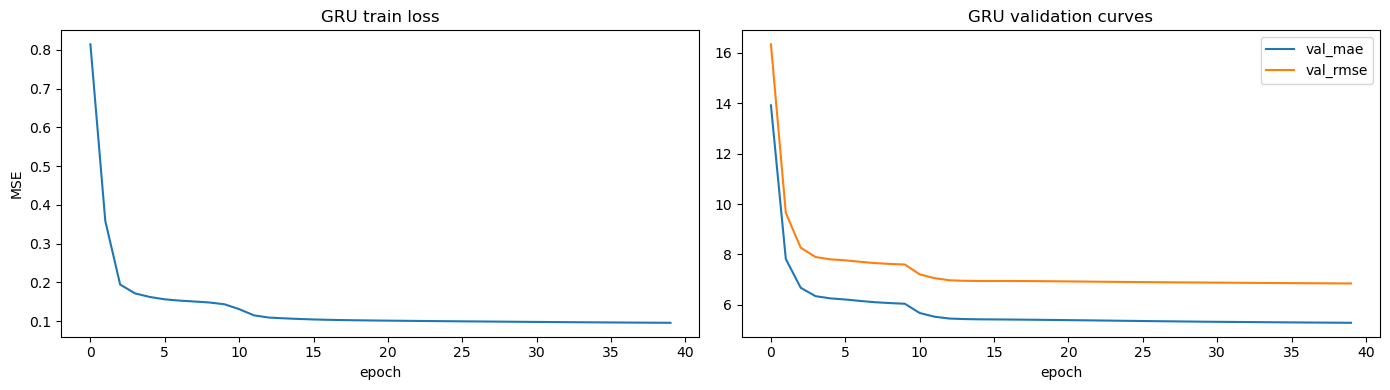

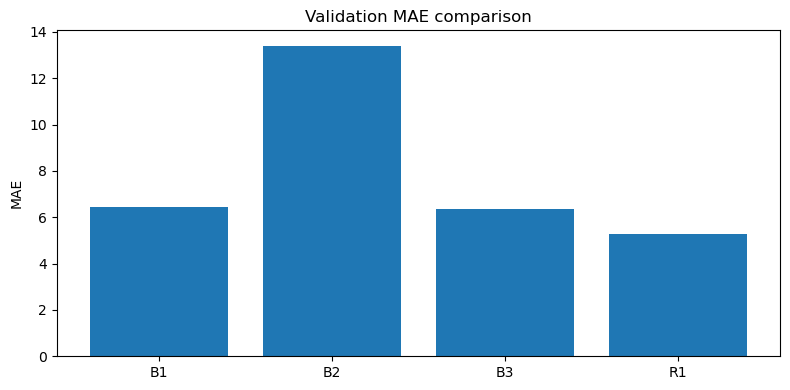

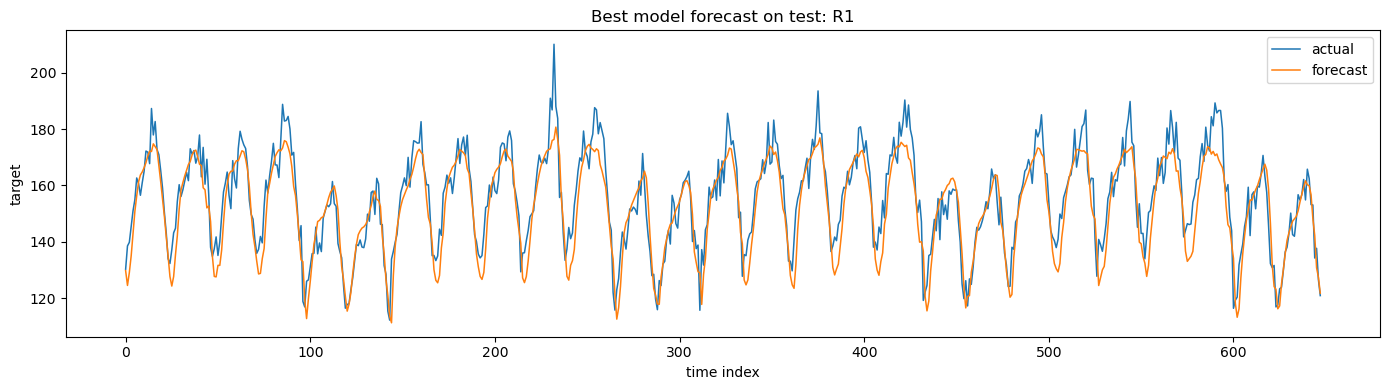

Validation leaderboard (best_val_mae):
  experiment_id  best_val_mae
3            R1      5.286434
2            B3      6.360191
0            B1      6.444815
1            B2     13.397980
Final test metrics for best model only: R1 {'mae': 6.257360399505238, 'rmse': 7.854264282045437, 'mape': 4.061110265995709}
Saved artifacts to: artifacts


In [5]:
def make_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out['lag_1'] = out['target'].shift(1)
    out['lag_7'] = out['target'].shift(7)
    out['lag_14'] = out['target'].shift(14)
    shifted = out['target'].shift(1)
    out['rolling_mean_7'] = shifted.rolling(7).mean()
    out['rolling_std_7'] = shifted.rolling(7).std()
    out['day_of_week'] = out['date'].dt.dayofweek
    out['hour'] = out['date'].dt.hour
    return out


def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    eps = 1e-8
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100.0
    return {'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}


def naive_last_pred(prev_last, eval_values):
    eval_values = np.asarray(eval_values, dtype=float)
    return np.concatenate([[prev_last], eval_values[:-1]]) if len(eval_values) else np.array([])


def baseline_b2_moving_average(history_values, eval_values, window):
    """B2 (moving-average): baseline — прогноз как среднее по последним `window` наблюдениям из уже известной истории (без утечки из будущего)."""
    hist = list(np.asarray(history_values, dtype=float))
    preds = []
    for i in range(len(eval_values)):
        preds.append(np.mean(hist[-window:]) if len(hist) >= window else np.mean(hist))
        hist.append(eval_values[i])
    return np.asarray(preds)


feat_df = make_features(df).dropna().reset_index(drop=True)
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'hour']

train_mask = feat_df['date'] <= train_df['date'].max()
val_mask = (feat_df['date'] > train_df['date'].max()) & (feat_df['date'] <= val_df['date'].max())
test_mask = feat_df['date'] > val_df['date'].max()

X_train = feat_df.loc[train_mask, feature_cols].values
y_train = feat_df.loc[train_mask, 'target'].values
X_val = feat_df.loc[val_mask, feature_cols].values
y_val = feat_df.loc[val_mask, 'target'].values
X_test = feat_df.loc[test_mask, feature_cols].values
y_test = feat_df.loc[test_mask, 'target'].values

scaler_b3 = StandardScaler()
X_train_sc = scaler_b3.fit_transform(X_train)
X_val_sc = scaler_b3.transform(X_val)
X_test_sc = scaler_b3.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
val_pred_b3 = ridge.predict(X_val_sc)


class SeqDataset(Dataset):
    def __init__(self, values, indices, window_size):
        self.values = values
        self.indices = np.asarray(indices)
        self.window_size = window_size

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]
        x = self.values[t - self.window_size:t]
        y = self.values[t]
        return torch.tensor(x, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)


class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)


series = df['target'].values.astype(np.float32)
scaler_gru = StandardScaler()
scaler_gru.fit(series[:train_end].reshape(-1, 1))
series_full_scaled = scaler_gru.transform(series.reshape(-1, 1)).reshape(-1)

all_t = np.arange(WINDOW_SIZE, len(series_full_scaled))
train_idx = all_t[all_t < train_end]
val_idx = all_t[(all_t >= train_end) & (all_t < val_end)]
test_idx = all_t[all_t >= val_end]

train_loader = DataLoader(SeqDataset(series_full_scaled, train_idx, WINDOW_SIZE), batch_size=BATCH_SIZE, shuffle=False)  # хронология: без shuffle (random split / перемешивание запрещены)
val_loader = DataLoader(SeqDataset(series_full_scaled, val_idx, WINDOW_SIZE), batch_size=BATCH_SIZE, shuffle=False)

model = GRURegressor(hidden_size=64).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'val_mae': [], 'val_rmse': [], 'val_mape': []}
best_val_mae = float('inf')
best_val_rmse = float('inf')
best_val_mape = float('inf')
best_state = None
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_pred_scaled, val_true_scaled = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            val_pred_scaled.append(model(xb).cpu().numpy())
            val_true_scaled.append(yb.numpy())

    val_pred_scaled = np.concatenate(val_pred_scaled)
    val_true_scaled = np.concatenate(val_true_scaled)
    val_pred = scaler_gru.inverse_transform(val_pred_scaled.reshape(-1, 1)).reshape(-1)
    val_true = scaler_gru.inverse_transform(val_true_scaled.reshape(-1, 1)).reshape(-1)
    m = calc_metrics(val_true, val_pred)

    history['train_loss'].append(float(np.mean(train_losses)))
    history['val_mae'].append(m['mae'])
    history['val_rmse'].append(m['rmse'])
    history['val_mape'].append(m['mape'])

    if m['mae'] < best_val_mae:
        best_val_mae = m['mae']
        best_val_rmse = m['rmse']
        best_val_mape = m['mape']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch

if best_state is None:
    raise RuntimeError('No best GRU state was saved')

torch.save(best_state, ARTIFACTS_DIR / 'best_gru.pt')

best_gru_config = {
    'model': 'GRURegressor',
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'best_epoch': best_epoch,
    'learning_rate': LEARNING_RATE,
    'optimizer': 'Adam',
    'seed': SEED,
    'scaler': 'StandardScaler(target fit on train only)',
    'device': str(DEVICE),
}
with open(ARTIFACTS_DIR / 'best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)


val_true_base = val_df['target'].values
val_pred_b1 = naive_last_pred(train_df['target'].iloc[-1], val_true_base)
val_pred_b2 = baseline_b2_moving_average(train_df['target'].values, val_true_base, MOVING_AVG_WINDOW)  # B2 moving-average

metrics_val_b1 = calc_metrics(val_true_base, val_pred_b1)
metrics_val_b2 = calc_metrics(val_true_base, val_pred_b2)
metrics_val_b3 = calc_metrics(y_val, val_pred_b3)
metrics_val_r1 = {'mae': best_val_mae, 'rmse': best_val_rmse, 'mape': best_val_mape}

val_board = {'B1': metrics_val_b1, 'B2': metrics_val_b2, 'B3': metrics_val_b3, 'R1': metrics_val_r1}
best_exp = min(val_board, key=lambda e: val_board[e]['mae'])
print('Best experiment by val MAE:', best_exp)


best_test = {'mae': np.nan, 'rmse': np.nan, 'mape': np.nan}
best_test_pred, best_test_true = None, None

if best_exp == 'B1':
    y_true = test_df['target'].values
    y_pred = naive_last_pred(val_df['target'].iloc[-1], y_true)
    best_test = calc_metrics(y_true, y_pred)
    best_test_pred, best_test_true = y_pred, y_true
elif best_exp == 'B2':
    y_true = test_df['target'].values
    hist_values = np.concatenate([train_df['target'].values, val_df['target'].values])
    y_pred = baseline_b2_moving_average(hist_values, y_true, MOVING_AVG_WINDOW)
    best_test = calc_metrics(y_true, y_pred)
    best_test_pred, best_test_true = y_pred, y_true
elif best_exp == 'B3':
    y_true = y_test
    y_pred = ridge.predict(X_test_sc)
    best_test = calc_metrics(y_true, y_pred)
    best_test_pred, best_test_true = y_pred, y_true
else:
    best_model = GRURegressor(hidden_size=64).to(DEVICE)
    best_model.load_state_dict(torch.load(ARTIFACTS_DIR / 'best_gru.pt', map_location=DEVICE))
    best_model.eval()

    test_loader = DataLoader(SeqDataset(series_full_scaled, test_idx, WINDOW_SIZE), batch_size=BATCH_SIZE, shuffle=False)
    pred_scaled, true_scaled = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            pred_scaled.append(best_model(xb).cpu().numpy())
            true_scaled.append(yb.numpy())

    pred_scaled = np.concatenate(pred_scaled)
    true_scaled = np.concatenate(true_scaled)
    y_pred = scaler_gru.inverse_transform(pred_scaled.reshape(-1, 1)).reshape(-1)
    y_true = scaler_gru.inverse_transform(true_scaled.reshape(-1, 1)).reshape(-1)
    best_test = calc_metrics(y_true, y_pred)
    best_test_pred, best_test_true = y_pred, y_true


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history['train_loss'])
ax[0].set_title('GRU train loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('MSE')

ax[1].plot(history['val_mae'], label='val_mae')
ax[1].plot(history['val_rmse'], label='val_rmse')
ax[1].set_title('GRU validation curves')
ax[1].set_xlabel('epoch')
ax[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gru_learning_curves.png', dpi=150)
plt.show()

exp_names = ['B1', 'B2', 'B3', 'R1']
val_maes = [val_board[e]['mae'] for e in exp_names]
plt.figure(figsize=(8, 4))
plt.bar(exp_names, val_maes)
plt.title('Validation MAE comparison')
plt.ylabel('MAE')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baselines_compare.png', dpi=150)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(best_test_true, label='actual', lw=1.1)
plt.plot(best_test_pred, label='forecast', lw=1.1)
plt.title(f'Best model forecast on test: {best_exp}')
plt.xlabel('time index')
plt.ylabel('target')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'best_forecast_test.png', dpi=150)
plt.show()


columns = [
    'experiment_id', 'task', 'dataset', 'seed', 'split_summary', 'window_size', 'horizon',
    'model_summary', 'features_summary', 'scaler', 'optimizer', 'lr', 'epochs_trained',
    'best_val_mae', 'best_val_rmse', 'best_val_mape', 'test_mae', 'test_rmse', 'test_mape', 'notes'
]

split_summary = f'train[0:{train_end}) val[{train_end}:{val_end}) test[{val_end}:{n})'
features_summary = 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week, hour'

rows = [
    {'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': SEED, 'split_summary': split_summary, 'window_size': np.nan, 'horizon': HORIZON, 'model_summary': 'naive-last', 'features_summary': 'last observed target', 'scaler': np.nan, 'optimizer': np.nan, 'lr': np.nan, 'epochs_trained': np.nan, 'best_val_mae': metrics_val_b1['mae'], 'best_val_rmse': metrics_val_b1['rmse'], 'best_val_mape': metrics_val_b1['mape'], 'test_mae': best_test['mae'] if best_exp == 'B1' else np.nan, 'test_rmse': best_test['rmse'] if best_exp == 'B1' else np.nan, 'test_mape': best_test['mape'] if best_exp == 'B1' else np.nan, 'notes': 'no training'},
    {'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': SEED, 'split_summary': split_summary, 'window_size': MOVING_AVG_WINDOW, 'horizon': HORIZON, 'model_summary': f'moving-average(window={MOVING_AVG_WINDOW})', 'features_summary': 'rolling history of target', 'scaler': np.nan, 'optimizer': np.nan, 'lr': np.nan, 'epochs_trained': np.nan, 'best_val_mae': metrics_val_b2['mae'], 'best_val_rmse': metrics_val_b2['rmse'], 'best_val_mape': metrics_val_b2['mape'], 'test_mae': best_test['mae'] if best_exp == 'B2' else np.nan, 'test_rmse': best_test['rmse'] if best_exp == 'B2' else np.nan, 'test_mape': best_test['mape'] if best_exp == 'B2' else np.nan, 'notes': 'no training'},
    {'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': SEED, 'split_summary': split_summary, 'window_size': np.nan, 'horizon': HORIZON, 'model_summary': 'Ridge(alpha=1.0)', 'features_summary': features_summary, 'scaler': 'StandardScaler(features fit on train only)', 'optimizer': np.nan, 'lr': np.nan, 'epochs_trained': np.nan, 'best_val_mae': metrics_val_b3['mae'], 'best_val_rmse': metrics_val_b3['rmse'], 'best_val_mape': metrics_val_b3['mape'], 'test_mae': best_test['mae'] if best_exp == 'B3' else np.nan, 'test_rmse': best_test['rmse'] if best_exp == 'B3' else np.nan, 'test_mape': best_test['mape'] if best_exp == 'B3' else np.nan, 'notes': 'lag/rolling/calendar features'},
    {'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset.csv', 'seed': SEED, 'split_summary': split_summary, 'window_size': WINDOW_SIZE, 'horizon': HORIZON, 'model_summary': 'GRU(hidden=64, layers=1)', 'features_summary': f'window of {WINDOW_SIZE} previous target values', 'scaler': 'StandardScaler(target fit on train only)', 'optimizer': 'Adam', 'lr': LEARNING_RATE, 'epochs_trained': best_epoch, 'best_val_mae': metrics_val_r1['mae'], 'best_val_rmse': metrics_val_r1['rmse'], 'best_val_mape': metrics_val_r1['mape'], 'test_mae': best_test['mae'] if best_exp == 'R1' else np.nan, 'test_rmse': best_test['rmse'] if best_exp == 'R1' else np.nan, 'test_mape': best_test['mape'] if best_exp == 'R1' else np.nan, 'notes': 'best state saved by validation MAE'},
]

runs_df = pd.DataFrame(rows, columns=columns)
runs_df.to_csv(ARTIFACTS_DIR / 'runs.csv', index=False)

print('Validation leaderboard (best_val_mae):')
print(runs_df[['experiment_id', 'best_val_mae']].sort_values('best_val_mae'))
print('Final test metrics for best model only:', best_exp, best_test)
print('Saved artifacts to:', ARTIFACTS_DIR)

## Кратко о контроле утечек данных

В этом пайплайне утечки закрыты так:
- temporal split строго по времени, без перемешивания;
- `lag_*` и `rolling_*` построены через `shift(1)` (без доступа к текущему/будущему таргету);
- масштабирование для `Ridge` обучается только на `X_train`, для `GRU` — только на train-части таргета;
- выбор лучшей модели идёт по validation;
- test используется один раз для финальной оценки лучшего подхода.